# Custom Optimizer - MyMomentumOptimizer

# SetUp

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Custom Optimizer

In [21]:
class MyMomentumOptimizer(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.01, momentum=0.9, name="MyMomentumOptimizer", **kwargs):
        super().__init__(name=name, learning_rate=learning_rate, **kwargs)
        self._learning_rate = learning_rate
        self._momentum = momentum
        self._velocities = []

    def build(self, var_list):
        self._velocities = [tf.Variable(tf.zeros_like(var), trainable=False) for var in var_list]

    def apply_gradients(self, grads_and_vars, name=None, **kwargs):
        grads_and_vars = list(grads_and_vars)
        if not self._velocities or len(self._velocities) != len(grads_and_vars):
            self.build([v for g, v in grads_and_vars])
        for (grad, var), velocity in zip(grads_and_vars, self._velocities):
            if grad is not None:
                velocity.assign(self._momentum * velocity - self._learning_rate * grad)
                var.assign_add(velocity)

# Load Data

In [22]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

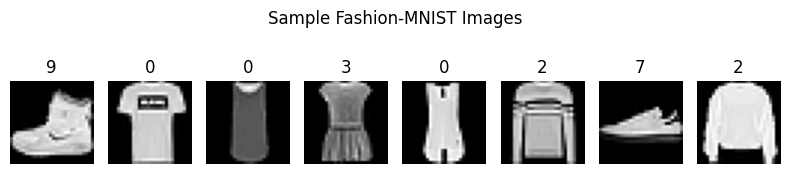

In [23]:
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

# Define a simple CNN

In [24]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile with custom optimizer

In [25]:
custom_optimizer = MyMomentumOptimizer(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Model

In [26]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test), verbose=2)

Epoch 1/5
938/938 - 45s - 48ms/step - accuracy: 0.7688 - loss: 0.6284 - val_accuracy: 0.8390 - val_loss: 0.4493
Epoch 2/5
938/938 - 80s - 85ms/step - accuracy: 0.8550 - loss: 0.3967 - val_accuracy: 0.8531 - val_loss: 0.3947
Epoch 3/5
938/938 - 83s - 88ms/step - accuracy: 0.8733 - loss: 0.3473 - val_accuracy: 0.8740 - val_loss: 0.3486
Epoch 4/5
938/938 - 85s - 91ms/step - accuracy: 0.8843 - loss: 0.3154 - val_accuracy: 0.8793 - val_loss: 0.3355
Epoch 5/5
938/938 - 79s - 84ms/step - accuracy: 0.8939 - loss: 0.2907 - val_accuracy: 0.8827 - val_loss: 0.3201


# Plot Training Results

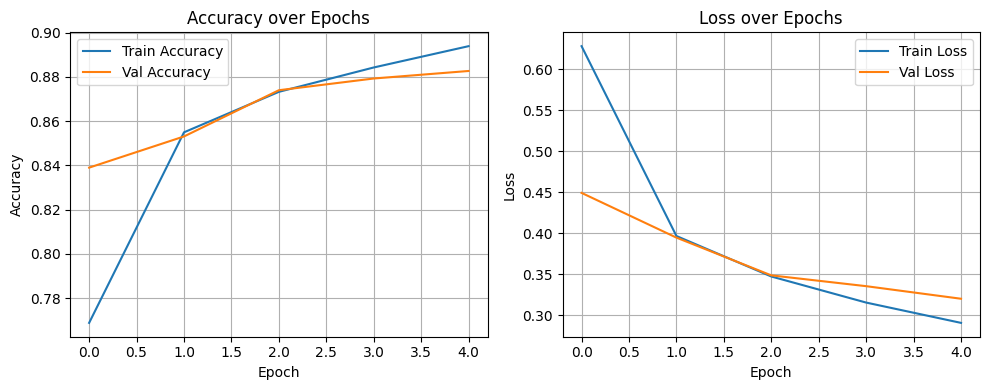

✅ Training with MyMomentumOptimizer completed.


In [27]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("✅ Training with MyMomentumOptimizer completed.")